# How many terminals can one server sustain? (closed networks & the knee)

An engineer models "N users hitting a server" as an open M/M/1 with rate `λ = N / think_time` —
and concludes the system dies the moment `λ > μ`. Real users don't work like that: while a
request is in flight, that user sends nothing. The longer the queue, the weaker the arrival
stream. This **self-throttling** is exactly what a **closed network** captures — and it changes
the answer qualitatively.

The model: N terminals "think" for `Z = 5 s` (an infinite-server *delay* node), then send a
request served in `b = 0.2 s` (FCFS node). Exact **Mean Value Analysis** (Reiser–Lavenberg 1980)
gives throughput `X(N)` and response time `R(N)` for every N.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.theory.networks.closed_network import ClosedNetworkCalc

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

THINK, SERVICE = 5.0, 0.2
ROUTING = np.array([[0.0, 1.0], [1.0, 0.0]])  # terminals <-> server

def solve(n):
    calc = ClosedNetworkCalc(method="mva")
    calc.set_sources(R=ROUTING, N=n)
    calc.set_nodes(b=[THINK, SERVICE], n=[None, 1])  # None = delay node
    res = calc.run()
    return res.throughput, res.v_node[1]  # X(N), R(N) at the server

ns = np.arange(1, 61)
xs, rs = zip(*(solve(int(n)) for n in ns))

## 1. The knee is at N\* = 1 + Z/b — and you can find it without solving anything

Two hard bounds hold for any closed network: `X(N) ≤ 1/b` (the server can't serve faster) and
`X(N) ≤ N/(Z+b)` (N users can't generate more). They cross at the **saturation point**

```
N* = 1 + Z/b = 1 + 5/0.2 = 26 terminals
```

Below N\* the system is effectively delay-bound (`R ≈ b`); above it every extra terminal adds a
full service time `b` to the response — the response-time asymptote is `R(N) → N·b − Z`.

R(10) = 0.30 s   R(26) = 0.92 s   R(40) = 3.01 s

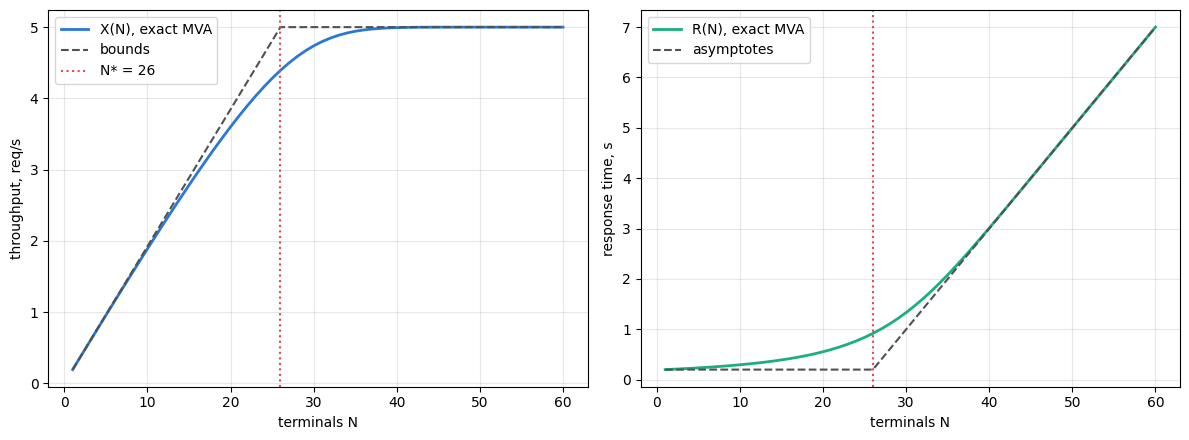

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
n_star = 1 + THINK / SERVICE

ax1.plot(ns, xs, lw=2, color="#2a78d6", label="X(N), exact MVA")
ax1.plot(ns, np.minimum(1 / SERVICE, ns / (THINK + SERVICE)), "--", color="#52514e", label="bounds")
ax1.axvline(n_star, color="#e34948", ls=":", label=f"N* = {n_star:.0f}")
ax1.set_xlabel("terminals N"); ax1.set_ylabel("throughput, req/s"); ax1.legend()

ax2.plot(ns, rs, lw=2, color="#1baf7a", label="R(N), exact MVA")
ax2.plot(ns, np.maximum(SERVICE, ns * SERVICE - THINK), "--", color="#52514e", label="asymptotes")
ax2.axvline(n_star, color="#e34948", ls=":")
ax2.set_xlabel("terminals N"); ax2.set_ylabel("response time, s"); ax2.legend()
plt.tight_layout()
print(f"R(10) = {rs[9]:.2f} s   R(26) = {rs[25]:.2f} s   R(40) = {rs[39]:.2f} s")

## 2. Why the open model lies here

The open M/M/1 approximation `λ = N/(Z+R₀)` predicts **infinite** latency for any N with
`λ > μ = 5` — i.e. for N > 26 the open model says "impossible". The closed system at N = 40 is
perfectly stable: `R = 3.0 s`, throughput exactly 5 req/s. Users *wait instead of overloading*:
the queue replaces the lost arrivals. The open model is only usable far below the knee, where
the two coincide.

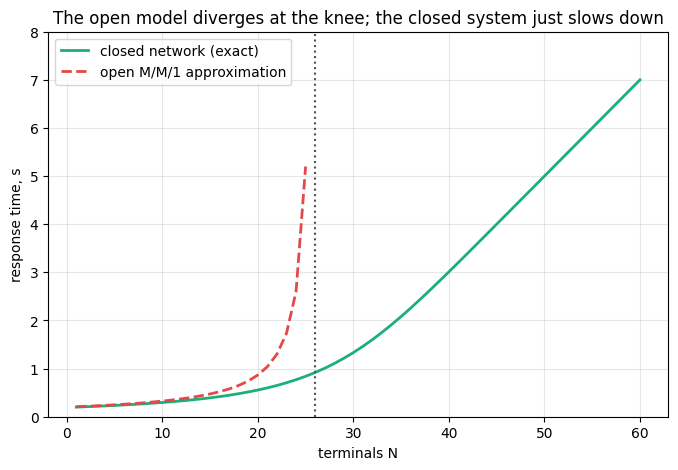

In [3]:
open_pred = []
for n in ns:
    lam = n / (THINK + SERVICE)  # naive open-model arrival rate
    rho = lam * SERVICE
    open_pred.append(SERVICE / (1 - rho) if rho < 1 else np.nan)

fig, ax = plt.subplots()
ax.plot(ns, rs, lw=2, color="#1baf7a", label="closed network (exact)")
ax.plot(ns, open_pred, lw=2, color="#e34948", ls="--", label="open M/M/1 approximation")
ax.axvline(n_star, color="#52514e", ls=":")
ax.set_xlabel("terminals N"); ax.set_ylabel("response time, s")
ax.set_ylim(0, 8); ax.legend()
ax.set_title("The open model diverges at the knee; the closed system just slows down")
plt.show()

## Takeaway

- Size interactive systems with **closed** models: users self-throttle, so the system degrades
  gracefully instead of dying at `ρ = 1`.
- The capacity knee `N* = 1 + Z/b` needs no solver — think time over service time, plus one.
- Past the knee, throughput is flat (`1/b`) and response grows **linearly**: `R ≈ N·b − Z`.
  Doubling terminals doesn't halve service — it doubles everyone's wait.
- The exact curve between the asymptotes is what `ClosedNetworkCalc` (MVA / Buzen) gives you;
  `examples/closed_network_example.py` is the script version of this notebook.